In [5]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Confirm paths to the folders created manually
data_path = '../data/processed/'
model_path = '../models/'

print("Environment ready. Folders verified.")

Environment ready. Folders verified.


In [6]:
# 1. Source real seismic patterns from USGS
url = 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2020-01-01&minmagnitude=4.0&limit=5000'
df_raw = pd.read_csv(url)

# 2. Define the 'Truth' (What the AI is trying to predict)
def get_label(mag):
    if mag < 4.5: return 0    # Safe
    elif mag < 5.5: return 1  # Watch
    elif mag < 6.5: return 2  # Danger
    else: return 3            # Evacuate

df_raw['risk_label'] = df_raw['mag'].apply(get_label)

# 3. Simulate Building Sensors (Arduino/ESP32 inputs)
n = len(df_raw)
np.random.seed(42)
df_raw['vibration_hz'] = (df_raw['mag'] * 1.5 + np.random.normal(0, 0.7, n)).clip(0.1, 15)
df_raw['acceleration_m2s'] = (df_raw['mag'] * 1.8 + np.random.normal(0, 0.5, n)).clip(0)
df_raw['fire_sensor'] = np.where(df_raw['vibration_hz'] > 8.0, np.random.uniform(40, 100, n), np.random.uniform(0, 10, n))
df_raw['structural_damage'] = (df_raw['vibration_hz'] > 11.0).astype(int)

# 4. Add "Quiet Days" (Important for a balanced model)
safe_days = pd.DataFrame({
    'vibration_hz': np.random.uniform(0.01, 1.5, 4000),
    'acceleration_m2s': np.random.uniform(0.01, 0.4, 4000),
    'fire_sensor': np.random.uniform(0, 5, 4000),
    'structural_damage': 0,
    'risk_label': 0
})

# 5. Final Feature Selection (Removing Magnitude to prevent cheating)
FEATURES = ['vibration_hz', 'acceleration_m2s', 'fire_sensor', 'structural_damage']
df_final = pd.concat([df_raw[FEATURES + ['risk_label']], safe_days]).reset_index(drop=True)

# 6. Normalize and Save
scaler = MinMaxScaler()
df_final[FEATURES] = scaler.fit_transform(df_final[FEATURES])
df_final.to_csv(os.path.join(data_path, 'sensor_data_clean.csv'), index=False)

print(f"Phase 1 Complete. Saved {len(df_final)} rows to {data_path}")

Phase 1 Complete. Saved 9000 rows to ../data/processed/


In [7]:
# 1. Prepare Data Split (The "Exam" Setup)
X = df_final[FEATURES]
y = df_final['risk_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Save the trained 'Brain' for future use
joblib.dump(model, os.path.join(model_path, 'seismic_risk_model.pkl'))

# 4. Evaluate Performance
y_pred = model.predict(X_test)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Watch', 'Danger', 'Evacuate']))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Safe       0.90      0.93      0.92      1318
       Watch       0.75      0.69      0.72       452
      Danger       0.66      0.75      0.70        28
    Evacuate       1.00      0.50      0.67         2

    accuracy                           0.86      1800
   macro avg       0.83      0.72      0.75      1800
weighted avg       0.86      0.86      0.86      1800



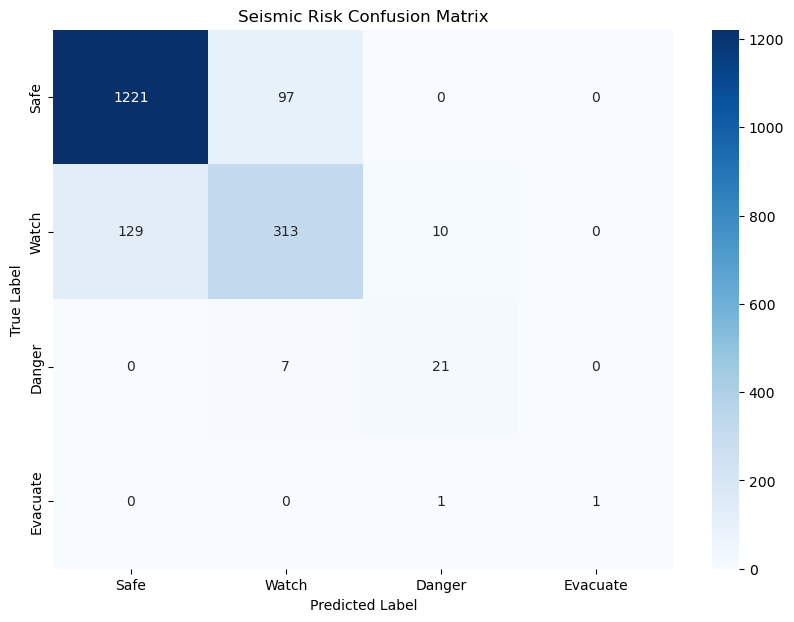

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix data
cm = confusion_matrix(y_test, y_pred)
labels = ['Safe', 'Watch', 'Danger', 'Evacuate']

# 2. Create the Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Seismic Risk Confusion Matrix')
plt.show()

In [10]:
def live_monitor_simulation(seconds=10):
    print("--- STARTING REAL-TIME STRUCTURAL MONITORING ---")
    labels = ['SAFE', 'WATCH', 'DANGER', 'EVACUATE']
    # Explicitly use the feature names the model expects
    FEATURES = ['vibration_hz', 'acceleration_m2s', 'fire_sensor', 'structural_damage']
    
    for i in range(seconds):
        if i < 6:
            vibration, accel, fire, damage = 0.15, 0.12, 1.2, 0
        else:
            # Simulate the emergency spike
            vibration, accel, fire, damage = 0.85, 0.90, 85.0, 1
            
        # Wrap in a DataFrame to remove the UserWarning
        current_reading = pd.DataFrame([[vibration, accel, fire, damage]], columns=FEATURES)
        prediction = model.predict(current_reading)[0]
        
        status = labels[prediction]
        print(f"Time {i}s | Vib: {vibration:.2f} | Fire: {fire:.1f} | STATUS: {status}")
        
        if status == 'EVACUATE' or status == 'DANGER':
            print("!!! WARNING: POTENTIAL SEISMIC THREAT DETECTED !!!")
        
        time.sleep(0.5)

live_monitor_simulation()

--- STARTING REAL-TIME STRUCTURAL MONITORING ---
Time 0s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 1s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 2s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 3s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 4s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 5s | Vib: 0.15 | Fire: 1.2 | STATUS: SAFE
Time 6s | Vib: 0.85 | Fire: 85.0 | STATUS: EVACUATE
!!! WARNING: POTENTIAL SEISMIC THREAT DETECTED !!!
Time 7s | Vib: 0.85 | Fire: 85.0 | STATUS: EVACUATE
!!! WARNING: POTENTIAL SEISMIC THREAT DETECTED !!!
Time 8s | Vib: 0.85 | Fire: 85.0 | STATUS: EVACUATE
!!! WARNING: POTENTIAL SEISMIC THREAT DETECTED !!!
Time 9s | Vib: 0.85 | Fire: 85.0 | STATUS: EVACUATE
!!! WARNING: POTENTIAL SEISMIC THREAT DETECTED !!!
